In [1]:
import os
import random
import xml.etree.ElementTree as ET
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributed as dist
from torch.utils.data import DataLoader, DistributedSampler,Dataset
from torchvision import transforms, models
from torchvision.transforms import ToTensor
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import FakeData
import torch.multiprocessing as mp
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [1]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")


NameError: name 'torch' is not defined

In [3]:
torch.cuda.set_device(0)

In [4]:
print(f"Using device: {torch.cuda.get_device_name(torch.cuda.current_device())}")

Using device: AMD Radeon RX 6700S


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


#  Обнаружение объектов

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html
* https://pyimagesearch.com/2021/11/01/training-an-object-detector-from-scratch-in-pytorch/
* https://pyimagesearch.com/2021/08/02/pytorch-object-detection-with-pre-trained-networks/

## Задачи для совместного разбора

1. Рассмотрите простейшую архитектуру для решения задачи object detection и процесс настройки модели.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Напишите функцию `parse_xml`, которая читает xml-файл с разметкой изображения из архива `animals.zip` и возвращает словарь, содержащий три ключа: 
```
{
        "raw": # словарь с ключами xmin, ymin, xmax, ymax
        "scaled": # словарь с ключами xmin, ymin, xmax, ymax
        "obj_name": # строка
}
```
В этом словаре `row` - абсолютные значения координат вершин bounding box, а `scaled` - относительные (нормированные на ширину и высоту изображения). Примените функцию к файлу `cat.0.xml` и выведите результат на экран.


- [ ] Проверено на семинаре

In [6]:
def parse_xml(file_path):
    import xml.etree.ElementTree as ET

    tree = ET.parse(file_path)
    root = tree.getroot()

    # Извлечение метки объекта
    obj_name = root.find('object/name').text

    # Извлечение координат bounding box
    bndbox = root.find('object/bndbox')
    xmin = float(bndbox.find('xmin').text)
    ymin = float(bndbox.find('ymin').text)
    xmax = float(bndbox.find('xmax').text)
    ymax = float(bndbox.find('ymax').text)

    # Извлечение размеров изображения
    size = root.find('size')
    width = float(size.find('width').text)
    height = float(size.find('height').text)

    raw = {"xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax}

    scaled = {
        "xmin": xmin / width,
        "ymin": ymin / height,
        "xmax": xmax / width,
        "ymax": ymax / height
    }

    return {"raw": raw, "scaled": scaled, "obj_name": obj_name}


In [7]:
file_path = os.path.join('Asirra_ cat vs dogs', 'cat.0.xml')
result = parse_xml(file_path)
print(result)

FileNotFoundError: [Errno 2] No such file or directory: 'Asirra_ cat vs dogs/cat.0.xml'

<p class="task" id="2"></p>

2\. Опишите датасет `AnimalDetectionDataset` на основе архива `animals.zip`. Реализуйте `__getitem__` таким образом, чтобы он возвращал три элемента: тензор с изображением, словарь с координатами bounding box и метку объекта. Предусмотрите возможность передавать извне при создании датасета набор преобразований для изображений, преобразование для метки объекта (для кодирования) и флаг, показывающий, нужно ли возвращать исходные или нормированные координаты bounding box.

- [ ] Проверено на семинаре

In [51]:
class AnimalDetectionDataset(Dataset):
    def __init__(self, root, transforms=None, target_transform=None, return_scaled=True):
        self.root = root
        self.transforms = transforms
        self.target_transform = target_transform
        self.return_scaled = return_scaled

        self.annotations = [
            os.path.join(root, fname)
            for fname in os.listdir(root)
            if fname.endswith('.xml')
        ]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        xml_file = self.annotations[idx]
        parsed = parse_xml(xml_file) 

        image_file = xml_file.replace('.xml', '.jpg')
        image = Image.open(image_file).convert("RGB")

        if self.transforms:
            image = self.transforms(image)
        else:
            image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0

        bbox = parsed["scaled"] if self.return_scaled else parsed["raw"]
        bbox = {key: torch.tensor(value, dtype=torch.float32) for key, value in bbox.items()}

        label = parsed["obj_name"]
        if self.target_transform:
            label = self.target_transform(label)

        return image, bbox, label

In [7]:
dataset = AnimalDetectionDataset(
    root="Asirra_ cat vs dogs",
    transforms=ToTensor(),
    return_scaled=True
)

image, bbox, label = dataset[0]
print("Image shape:", image.shape)
print("Bounding box:", bbox)
print("Label:", label)

Image shape: torch.Size([3, 374, 500])
Bounding box: {'xmin': tensor(0.2520), 'ymin': tensor(0.2219), 'xmax': tensor(0.7080), 'ymax': tensor(0.6497)}
Label: cat


<p class="task" id="3"></p>

3\. Создайте объект класса `AnimalDetectionDataset` без применения преобразований и со значением `return_scaled=False`. Напишите функцию `show_image_with_bounding_box` для визуализации изображения с добавлением на него bounding box и подписи объекта. Продемонстрируйте работу функцию на изображении собаки и кошки.

- [ ] Проверено на семинаре

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
from torch.utils.data import Dataset

class AnimalDetectionDataset(Dataset):
    def __init__(self, root, transforms=None, return_scaled=False):
        self.root = root
        self.transforms = transforms
        self.return_scaled = return_scaled

        self.annotations = [
            os.path.join(root, fname)
            for fname in os.listdir(root)
            if fname.endswith('.xml')
        ]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        # Загружаем XML
        xml_file = self.annotations[idx]
        parsed = parse_xml(xml_file)

        # Загружаем изображение
        image_path = xml_file.replace('.xml', '.jpg')
        image = Image.open(image_path).convert("RGB")

        # Применяем преобразования, если они заданы
        if self.transforms:
            image = self.transforms(image)
        else:
            raise ValueError("Необходимо передать transforms для преобразования изображения!")

        # Преобразуем bounding box в тензор
        bbox = parsed["scaled"] if self.return_scaled else parsed["raw"]
        bbox = torch.tensor([bbox["xmin"], bbox["ymin"], bbox["xmax"], bbox["ymax"]], dtype=torch.float32)

        # Преобразуем метку (cat -> 0, dog -> 1)
        label = 0 if parsed["obj_name"] == "cat" else 1

        return image, bbox, label

def show_image_with_bounding_box(image, bbox, label):
    fig, ax = plt.subplots(1, figsize=(8, 8))

    # Если изображение - тензор, преобразуем в numpy
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).numpy()

    ax.imshow(image)

    rect = patches.Rectangle(
        (bbox[0], bbox[1]), 
        bbox[2] - bbox[0],  
        bbox[3] - bbox[1],  
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)

    # Интерпретация метки
    class_name = "dog" if label == 1 else "cat"

    ax.text(
        bbox[0], bbox[1] - 10,
        class_name, color='red', fontsize=12, backgroundcolor='white'
    )

    plt.axis('off')
    plt.show()

dataset = AnimalDetectionDataset(
    root="Asirra_ cat vs dogs",
    transforms=None,
    return_scaled=False 
)

In [9]:

transform = transforms.Compose([
    transforms.ToTensor(), 
])

dataset = AnimalDetectionDataset(
    root="Asirra_ cat vs dogs",
    transforms=transform,
    return_scaled=False 
)

Dog found at index 136


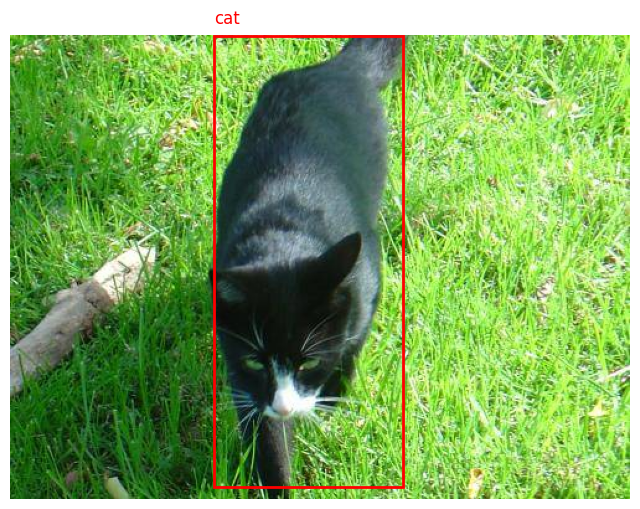

Cat found at index 0


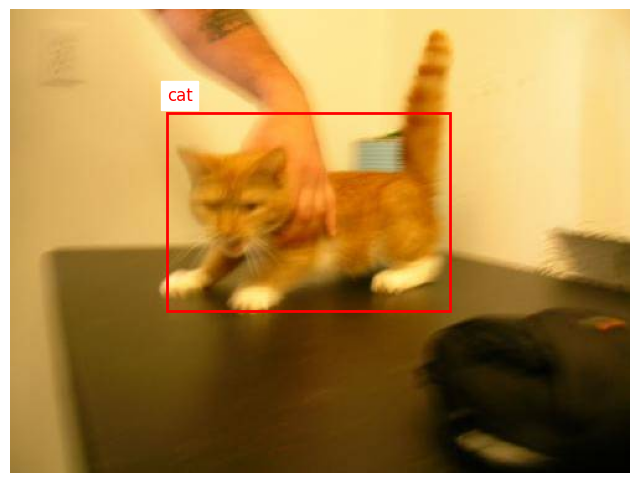

In [10]:

dog_idx = next((i for i, (_, _, label) in enumerate(dataset) if label == 1), None)
if dog_idx is not None:
    print(f"Dog found at index {dog_idx}")
    image, bbox, label = dataset[dog_idx]
    show_image_with_bounding_box(image, bbox, "dog")
else:
    print("Dog not found.")

cat_idx = next((i for i, (_, _, label) in enumerate(dataset) if label == 0), None)
if cat_idx is not None:
    print(f"Cat found at index {cat_idx}")
    image, bbox, label = dataset[cat_idx]
    show_image_with_bounding_box(image, bbox, "cat")
else:
    print("Cat not found.")


<p class="task" id="4"></p>

4\. Напишите модель для решения задачи выделения объектов. Реализуйте двухголовую сеть, одна голова которой предсказывает метку объекта (задача классификации), а вторая голова предсказывает 4 координаты вершин bounding box (задача регрессии). В качестве backbone используйте модель resnet50 из пакета `torchvision`.

- [ ] Проверено на семинаре

In [65]:
class TwoHeadedModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet50(pretrained=True)
        
        # Замораживаем слои backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Изменяем последний слой
        self.backbone.fc = nn.Identity()

        # Головка классификации
        self.classifier = nn.Linear(2048, num_classes)
        
        # Головка регрессии
        self.regressor = nn.Linear(2048, 4)

    def forward(self, x):
        features = self.backbone(x)
        class_logits = self.classifier(features)
        bbox_preds = self.regressor(features)
        return class_logits, bbox_preds


<p class="task" id="5"></p>

5\. Разбейте набор данных на обучающее и валидационное множество. Обучите модель, описанную в задаче 4. При создании датасета не забудьте указать преобразования, соответствующие модели ResNet. 

Используйте сумму MSELoss (для расчета ошибки на задаче регрессии) и CrossEntropyLoss (для расчета ошибки на задачи классификации) для настройки весов модели. Для ускорения процесса обучения слои backbone можно заморозить. Во время обучения выводите на экран значения функции потерь на обучающем и валидационном множестве. Используя обученную модель, получите предсказания для изображения кошки и собаки и отрисуйте их. Выполните процедуру, обратную нормализации, чтобы корректно отобразить фотографии.

- [ ] Проверено на семинаре

In [66]:
# Преобразования для ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Путь к данным
data_root = "Asirra_ cat vs dogs"

# Создаём датасет
dataset = AnimalDetectionDataset(root=data_root, transforms=transform, return_scaled=True)

# Разделяем на обучающее и валидационное множества
from sklearn.model_selection import train_test_split
train_indices, val_indices = train_test_split(range(len(dataset)), test_size=0.2, random_state=42)
train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)

# DataLoader
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [67]:
# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Модель
model = TwoHeadedModel(num_classes=2).to(device)

# Оптимизатор и функции потерь
optimizer = optim.Adam(model.parameters(), lr=1e-3)
classification_loss_fn = nn.CrossEntropyLoss()
regression_loss_fn = nn.MSELoss()


In [68]:
# Цикл обучения
num_epochs = 15
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for images, bboxes, labels in train_loader:
        images, bboxes, labels = images.to(device), bboxes.to(device), labels.to(device)

        # Прямой проход
        class_logits, bbox_preds = model(images)
        classification_loss = classification_loss_fn(class_logits, labels)
        regression_loss = regression_loss_fn(bbox_preds, bboxes)
        loss = classification_loss + regression_loss

        # Обратный проход
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, bboxes, labels in val_loader:
            images, bboxes, labels = images.to(device), bboxes.to(device), labels.to(device)

            class_logits, bbox_preds = model(images)
            classification_loss = classification_loss_fn(class_logits, labels)
            regression_loss = regression_loss_fn(bbox_preds, bboxes)
            loss = classification_loss + regression_loss

            val_loss += loss.item()

    print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss / len(train_loader):.4f}, "
          f"Val Loss: {val_loss / len(val_loader):.4f}")


Epoch [1/15], Train Loss: 1.1327, Val Loss: 0.9053
Epoch [2/15], Train Loss: 0.7977, Val Loss: 0.6860
Epoch [3/15], Train Loss: 0.7328, Val Loss: 0.4939
Epoch [4/15], Train Loss: 0.5029, Val Loss: 0.4170
Epoch [5/15], Train Loss: 0.4760, Val Loss: 0.3832
Epoch [6/15], Train Loss: 0.3776, Val Loss: 0.2615
Epoch [7/15], Train Loss: 0.3072, Val Loss: 0.2693
Epoch [8/15], Train Loss: 0.3062, Val Loss: 0.2011
Epoch [9/15], Train Loss: 0.2418, Val Loss: 0.1969
Epoch [10/15], Train Loss: 0.2348, Val Loss: 0.1897
Epoch [11/15], Train Loss: 0.2051, Val Loss: 0.1730
Epoch [12/15], Train Loss: 0.1901, Val Loss: 0.1680
Epoch [13/15], Train Loss: 0.1803, Val Loss: 0.1468
Epoch [14/15], Train Loss: 0.1641, Val Loss: 0.1362
Epoch [15/15], Train Loss: 0.1572, Val Loss: 0.1290


In [69]:
def denormalize(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    image_tensor = image_tensor * std + mean
    return image_tensor.squeeze().permute(1, 2, 0).clip(0, 1).cpu().numpy()

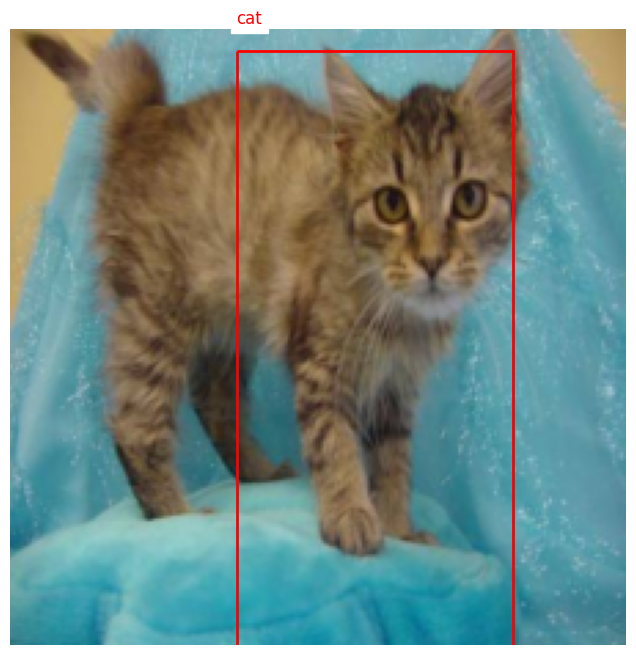

In [70]:
def show_image_with_bounding_box(image, bbox, label):
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)

    rect = patches.Rectangle(
        (bbox[0], bbox[1]),
        bbox[2] - bbox[0],
        bbox[3] - bbox[1],
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(
        bbox[0], bbox[1] - 10,
        label, color='red', fontsize=12, backgroundcolor='white'
    )
    plt.axis('off')
    plt.show()

# Пример предсказаний
model.eval()
with torch.no_grad():
    image, bbox, label = val_dataset[0]  # Пример из валидации
    image_tensor = image.unsqueeze(0).to(device)
    class_logits, bbox_preds = model(image_tensor)
    pred_class = torch.argmax(class_logits, dim=1).item()
    pred_bbox = bbox_preds[0].cpu().numpy()

    # Обратная нормализация
    image_np = denormalize(image)

    # Отрисовка
    show_image_with_bounding_box(
        image_np,
        [pred_bbox[0] * 224, pred_bbox[1] * 224, pred_bbox[2] * 224, pred_bbox[3] * 224],
        "cat" if pred_class == 0 else "dog"
    )

<p class="task" id="6"></p>

6\. Найдите в сети несколько изображений котов и собак. Используя любой инструмент для разметки (например, [CVAT](https://www.cvat.ai/)), выделите котов и собак на изображениях. Вставьте скриншот экспортированного файла с разметкой. Используя полученные изображения, визуализируйте разметку и bounding boxes, полученные при помощи модели.

- [ ] Проверено на семинаре

In [122]:
def visualize_annotations(image_path, annotation_path):
    # Парсим XML-аннотацию
    parsed = parse_xml(annotation_path)
    
    # Открываем изображение
    image = Image.open(image_path)
    width, height = image.size
    
    # Извлекаем координаты bounding box
    bbox = parsed["raw"]
    label = parsed["obj_name"]
    
    # Визуализация
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)
    
    rect = patches.Rectangle(
        (bbox["xmin"], bbox["ymin"]),
        bbox["xmax"] - bbox["xmin"],
        bbox["ymax"] - bbox["ymin"],
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(
        bbox["xmin"], bbox["ymin"] - 10,
        label, color='red', fontsize=12, backgroundcolor='white'
    )
    
    plt.axis('off')
    plt.show()

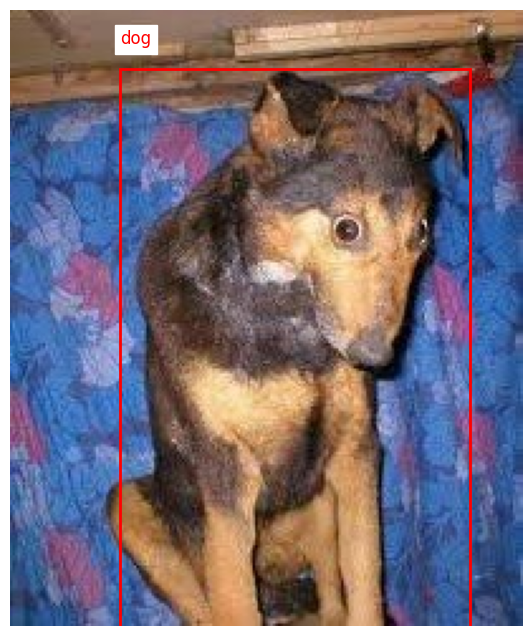

In [123]:
image_file = "/mnt/c/Users/n.sedov/Documents/vscode docs/ITiABD-PM22-7-Nikolay-Sedov/DL/lmao_animals/images/scale_12001.jpg"  # Путь к изображению
annotation_file = "/mnt/c/Users/n.sedov/Documents/vscode docs/ITiABD-PM22-7-Nikolay-Sedov/DL/lmao_animals/labels/scale_12001.xml"  # Путь к XML-аннотации

visualize_annotations(image_file, annotation_file)


<p class="task" id="7"></p>

7*\. Повторите решение предыдущей задачи, используя модель `fasterrcnn_resnet50_fpn`. Замените слой для предсказания bounding box на `FastRCNNPredictor` с нужным количеством классов. 

- [ ] Проверено на семинаре

In [3]:
class AnimalDetectionDataset(Dataset):
    def __init__(self, root, transforms=None, target_transform=None, return_scaled=True):
        self.root = root
        self.transforms = transforms
        self.target_transform = target_transform
        self.return_scaled = return_scaled

        self.annotations = [
            os.path.join(root, fname)
            for fname in os.listdir(root)
            if fname.endswith('.xml')
        ]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        xml_file = self.annotations[idx]
        parsed = parse_xml(xml_file)
    
        image_file = xml_file.replace('.xml', '.jpg')
        image = Image.open(image_file).convert("RGB")
    
        if self.transforms:
            image = self.transforms(image)
        else:
            image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
    
        bbox = parsed["scaled"] if self.return_scaled else parsed["raw"]
        boxes = [[bbox["xmin"], bbox["ymin"], bbox["xmax"], bbox["ymax"]]]
        boxes = torch.tensor(boxes, dtype=torch.float32)
    
        label = 1 if parsed["obj_name"] == "dog" else 2  # 1 для "dog", 2 для "cat"
        labels = torch.tensor([label], dtype=torch.int64)
    
        # Возвращаем изображение и target в формате, ожидаемом моделью
        target = {"boxes": boxes, "labels": labels}
        return image, target


In [4]:
def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets) 


In [5]:
# Преобразования для ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_root = "Asirra_ cat vs dogs"

dataset = AnimalDetectionDataset(root=data_root, transforms=transform, return_scaled=True)

# Разделяем на обучающее и валидационное множества
from sklearn.model_selection import train_test_split
train_indices, val_indices = train_test_split(range(len(dataset)), test_size=0.2, random_state=42)
train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)

batch_size = 32
# DataLoader
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn
)



In [7]:
# Инициализация модели
num_classes = 3  # 2 (cat, dog) + 1 (background)
model = fasterrcnn_resnet50_fpn(pretrained=True)

# Замена предиктора
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Оптимизатор только для головы модели
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)



In [9]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    # Тренировка
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    lr_scheduler.step()

    # Валидация
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            predictions = model(images)

            for pred, target in zip(predictions, targets):
                pred_boxes = pred['boxes']
                pred_labels = pred['labels']
                pred_scores = pred['scores']

                # Фильтрация по threshold
                pred_labels = pred_labels[pred_scores >= 0.2]

                true_labels = target['labels']

                val_correct += len(set(pred_labels.tolist()) & set(true_labels.tolist()))
                val_total += len(true_labels)

    val_accuracy = val_correct / val_total if val_total > 0 else 0

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Train Loss: {total_loss / len(train_loader):.4f}, "
        f"Val Accuracy: {val_accuracy:.4f}"
    )


Epoch [1/10], Train Loss: 0.3120, Val Accuracy: 0.5500
Epoch [2/10], Train Loss: 0.1122, Val Accuracy: 0.9864
Epoch [3/10], Train Loss: 0.1054, Val Accuracy: 1.0000
Epoch [4/10], Train Loss: 0.1004, Val Accuracy: 1.0000
Epoch [5/10], Train Loss: 0.0984, Val Accuracy: 1.0000
Epoch [6/10], Train Loss: 0.0942, Val Accuracy: 1.0000
Epoch [7/10], Train Loss: 0.0886, Val Accuracy: 1.0000
Epoch [8/10], Train Loss: 0.0872, Val Accuracy: 1.0000
Epoch [9/10], Train Loss: 0.0849, Val Accuracy: 1.0000
Epoch [10/10], Train Loss: 0.0829, Val Accuracy: 1.0000


In [10]:
# Заморозка backbone
for param in model.backbone.parameters():
    param.requires_grad = True


In [11]:
def show_image_with_bounding_box(image, boxes, labels, scores, class_names, threshold=0.05):
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)

    has_boxes = False

    for box, label, score in zip(boxes, labels, scores):
        if score >= threshold:
            has_boxes = True
            rect = patches.Rectangle(
                (box[0], box[1]),
                box[2] - box[0],
                box[3] - box[1],
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                box[0], box[1] - 10,
                f"{class_names[label]}: {score:.2f}",
                color='red', fontsize=12, backgroundcolor='white'
            )

    if not has_boxes:
        print("No predictions above the threshold.")
    else:
        print("Boxes visualized.")

    plt.axis('off')
    plt.show()


In [13]:
def visualize_random_prediction(dataset, model, class_names, threshold=0.5):
    def denormalize(image_tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        return image_tensor * std + mean

    random_idx = random.randint(0, len(dataset) - 1)
    image, target = dataset[random_idx]

    image_tensor = image.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        predictions = model(image_tensor)[0]

    boxes = predictions["boxes"].cpu().numpy()
    labels = predictions["labels"].cpu().numpy()
    scores = predictions["scores"].cpu().numpy()

    # Выводим предсказания для отладки
    print("Predictions:")
    for box, label, score in zip(boxes, labels, scores):
        print(f"Label: {class_names[label]}, Score: {score:.2f}, Box: {box}")

    denormalized_image = denormalize(image.unsqueeze(0)).squeeze(0).permute(1, 2, 0).clip(0, 1).numpy()

    show_image_with_bounding_box(denormalized_image, boxes, labels, scores, class_names, threshold)

In [19]:
class_names = {1: "dog", 2: "cat"}

Predictions:
Label: dog, Score: 0.37, Box: [0.17330194 0.15200475 0.8926298  1.004574  ]
Label: dog, Score: 0.37, Box: [0.        0.        1.6651222 1.5440995]
Label: dog, Score: 0.35, Box: [0.15006031 0.0213435  0.85349685 0.4279636 ]
Label: dog, Score: 0.35, Box: [0.02382765 0.06185118 0.5175147  0.92384464]
Label: cat, Score: 0.34, Box: [0.16155711 0.01743258 0.86880094 0.42285758]
Label: dog, Score: 0.34, Box: [0.02575516 0.01889806 0.7166001  0.617277  ]
Label: dog, Score: 0.34, Box: [0.01640108 0.01246894 0.45633596 0.40727878]
Label: dog, Score: 0.34, Box: [0.01065397 0.00835504 0.2964309  0.27290502]
Label: dog, Score: 0.34, Box: [0.00199974 0.00035253 0.05563973 0.01151496]
Label: cat, Score: 0.34, Box: [0.17397691 0.06584664 0.93057656 0.97030324]
Label: cat, Score: 0.30, Box: [0.01329279 0.02366176 0.41634068 0.80819535]
Label: cat, Score: 0.30, Box: [0.0226119  0.01810736 0.70822275 0.6184789 ]
Label: cat, Score: 0.30, Box: [0.01439943 0.01194722 0.45100126 0.40807176]
Lab

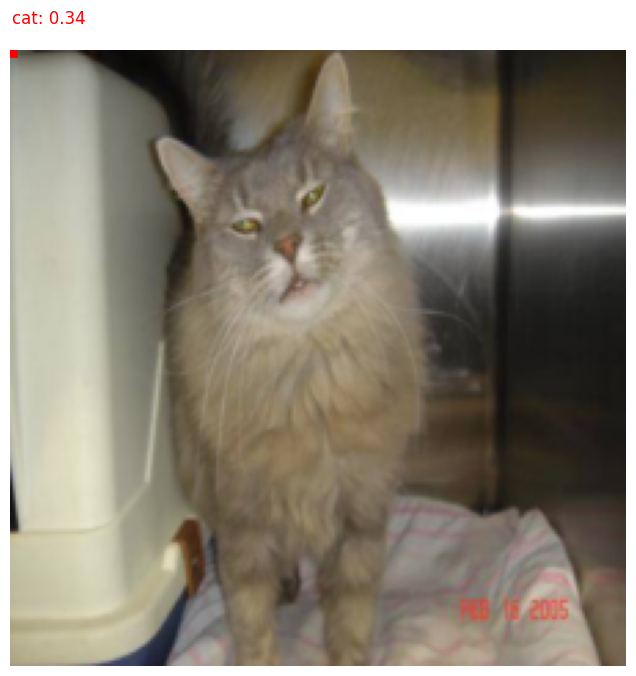

In [28]:
visualize_random_prediction(dataset, model, class_names, threshold=0.3)  # Уменьшите порог


## Обратная связь
- [ ] Хочу получить обратную связь по решению